# Analysis: 20250616

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data, platemap = pr.load_platereader_data("./data/20250616-160504-cytation5-pure-timecourse-gfp-ppk-cp-biotek-cdk.txt", "20250616-PPK CP-CK platemap.csv")

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

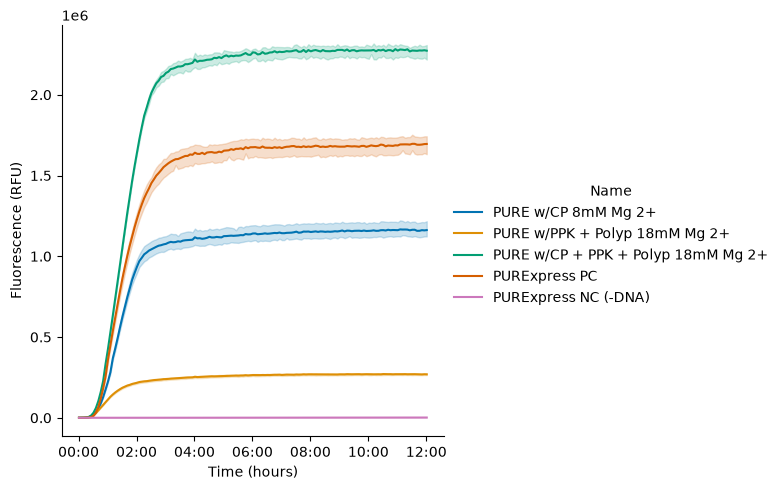

In [4]:
#| label: fig:kinetics-exp5

p = pr.plot_curves(data, palette="colorblind")
p.savefig("plot1-timeseries")

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

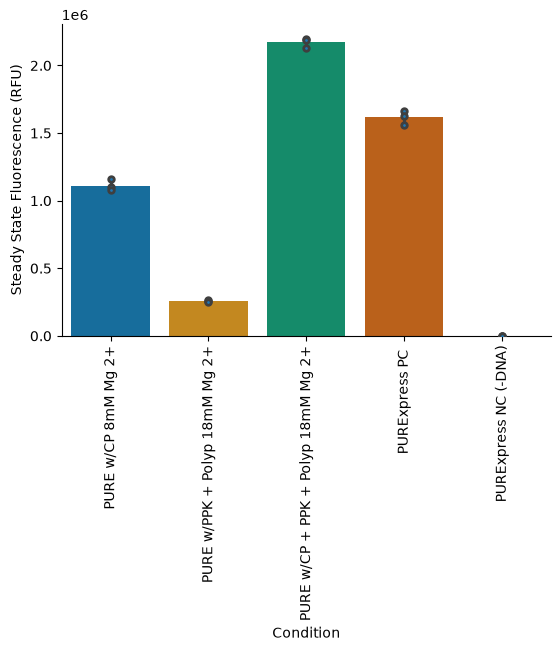

In [5]:
#| label: fig:endpoint-exp5

p1= pr.plot_steadystate(data, palette="colorblind")
plt.xlabel("Condition")
p1.savefig("plot2-endpoint")

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x14b8af9d0>,
                                                              Velocity  \
                                                                  Time   
 Name                               Read                                 
 PURE w/CP + PPK + Polyp 18mM Mg 2+ GFP-Gext 0 days 01:37:02.985893445   
 PURE w/CP 8mM Mg 2+                GFP-Gext 0 days 01:30:11.183020599   
 PURE w/PPK + Polyp 18mM Mg 2+      GFP-Gext 0 days 01:16:15.056125978   
 PURExpress NC (-DNA)               GFP-Gext 0 days 08:22:11.208282580   
 PURExpress PC                      GFP-Gext 0 days 01:35:03.233243742   
 
                                                                    \
                                                   Data        Max   
 Name                               Read                             
 PURE w/CP + PPK + Polyp 18mM Mg 2+ GFP-Gext 1142988.56 1380549.46   
 PURE w/CP 8mM Mg 2+                GFP-Gext  584893.79  793465.68   
 PURE w/PP

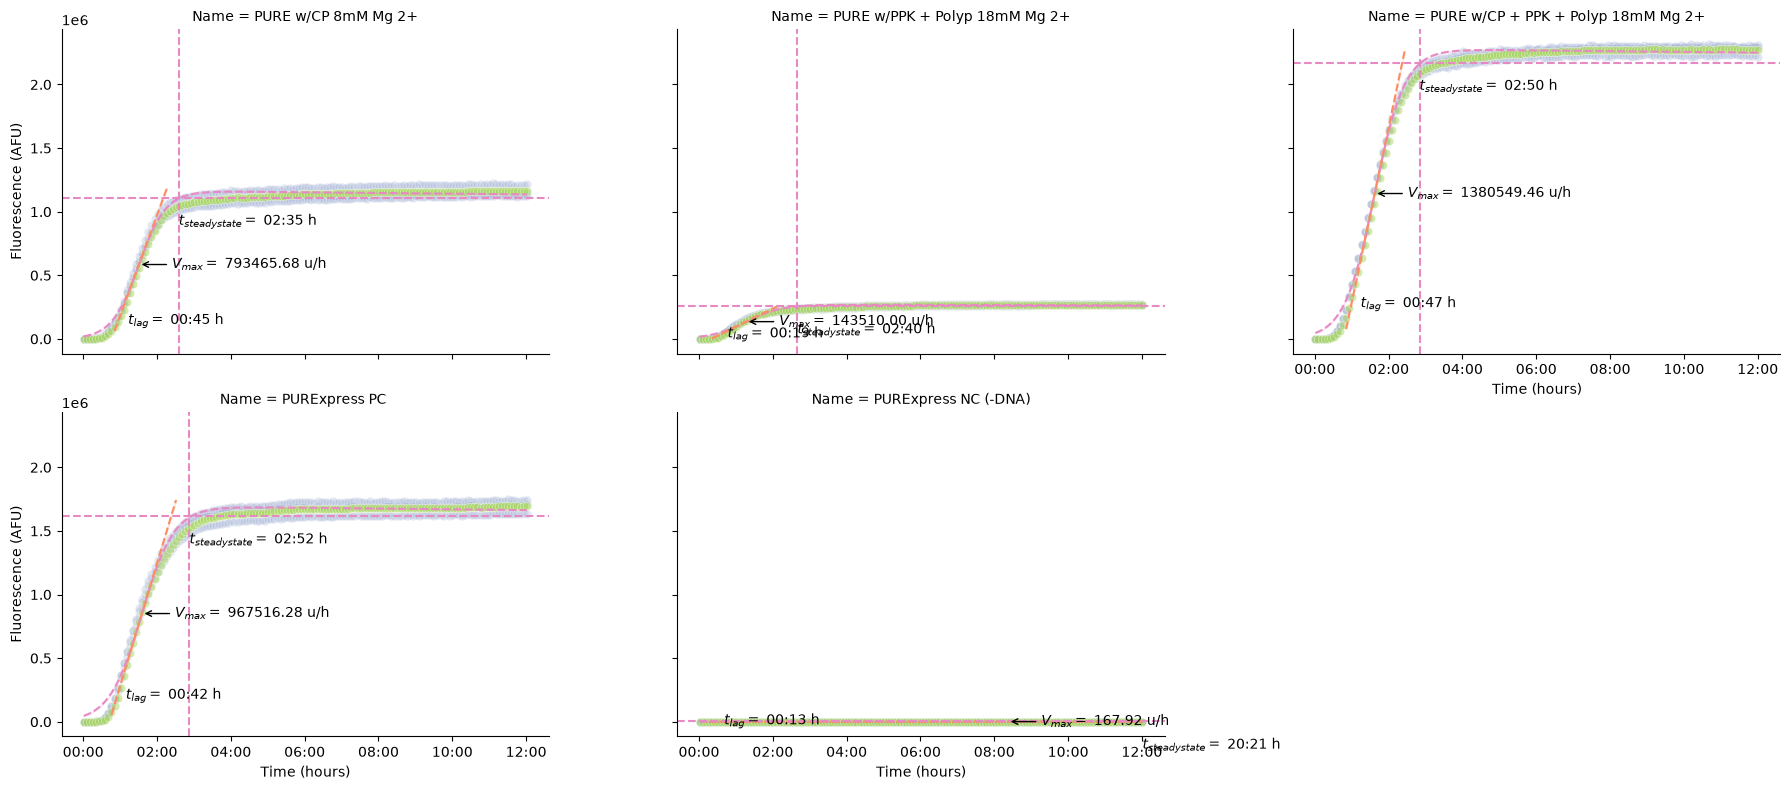

In [6]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [7]:
pr.kinetic_analysis(data)

Velocity  \
                                                                      Time   
Name                               Read     Well                             
PURE w/CP 8mM Mg 2+                GFP-Gext A1   0 days 01:30:07.863161245   
                                            A4   0 days 01:29:58.261148808   
                                            A7   0 days 01:30:27.424751745   
PURE w/PPK + Polyp 18mM Mg 2+      GFP-Gext E1   0 days 01:15:04.321389765   
                                            E4   0 days 01:16:57.907030324   
                                            E7   0 days 01:16:42.939957846   
PURE w/CP + PPK + Polyp 18mM Mg 2+ GFP-Gext G1   0 days 01:37:33.741868998   
                                            G4   0 days 01:37:33.841575404   
                                            G7   0 days 01:36:01.374235934   
PURExpress PC                      GFP-Gext I1   0 days 01:34:43.919341122   
                                            I4   0 days 01:35:36.974893768   
                                            I7   0 days 01:34:48.805496338   
PURExpress NC (-DNA)               GFP-Gext K1   0 days 08:08:45.253692135   
                                            K4   0 days 08:29:27.686541685   
                                            K7   0 days 08:28:20.684613921   

                                                                        \
                                                       Data        Max   
Name                               Read     Well                         
PURE w/CP 8mM Mg 2+                GFP-Gext A1    577707.26  795271.55   
                                            A4    610730.62  835927.11   
                                            A7    566243.48  749198.39   
PURE w/PPK + Polyp 18mM Mg 2+      GFP-Gext E1    137862.74  152876.95   
                                            E4    136843.75  141191.16   
                                            E7    132830.86  136461.90   
PURE w/CP + PPK + Polyp 18mM Mg 2+ GFP-Gext G1   1155846.19 1397373.22   
                                            G4   1153052.18 1369855.59   
                                            G7   1120067.29 1374419.57   
PURExpress PC                      GFP-Gext I1    876520.38 1008975.64   
                                            I4    819464.06  921292.90   
                                            I7    855933.66  972280.30   
PURExpress NC (-DNA)               GFP-Gext K1      1443.10     184.98   
                                            K4      1420.61     171.83   
                                            K7      1226.86     146.94   

                                                                       Lag  \
                                                                      Time   
Name                               Read     Well                             
PURE w/CP 8mM Mg 2+                GFP-Gext A1   0 days 00:46:32.723506567   
                                            A4   0 days 00:46:08.091340752   
                                            A7   0 days 00:45:06.547940028   
PURE w/PPK + Polyp 18mM Mg 2+      GFP-Gext E1   0 days 00:20:57.881236624   
                                            E4   0 days 00:18:48.754375707   
                                            E7   0 days 00:18:18.730395590   
PURE w/CP + PPK + Polyp 18mM Mg 2+ GFP-Gext G1   0 days 00:47:55.978850932   
                                            G4   0 days 00:47:03.604016270   
                                            G7   0 days 00:47:07.595983780   
PURExpress PC                      GFP-Gext I1   0 days 00:42:36.516424842   
                                            I4   0 days 00:42:14.876379010   
                                            I7   0 days 00:41:59.594741649   
PURExpress NC (-DNA)               GFP-Gext K1   0 days 00:20:40.420628610   
                                            K4   0 days 00:13:24.676849189   
  